# Setup

## Import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import warnings

# import local utils
import utils.preprocessing as preprocessing
import utils.dataloader as dataloader

plt.style.use(['science'])
warnings.filterwarnings('ignore')

## Set globals

In [2]:
PLOT_DURATION_LIMIT = 60
RAW_DATA_DIR = "./raw"

## Data loading and preprocessing

In [3]:
experiments = dataloader.load_experiment_data(RAW_DATA_DIR)

print(f"Loaded experiments: {list(experiments.keys())}")
print(f"Systems loaded (for Capsule as example): {list(experiments['capsule'].keys())}")

Loaded experiments: ['vcluster', 'kubezoo', 'capsule-proxy', 'capsule', 'kubevirt']
Systems loaded (for Capsule as example): ['control_plane', 'network', 'workload', 'storage']


In [368]:
import matplotlib as mathplotlib
def save_plot(fig, filename):
    # Save without any axis title
    # Remove titles from all axes before saving
    for ax in fig.get_axes():
        ax.set_title('')  # Remove individual subplot titles
    fig.savefig(f'{filename}.png', bbox_inches='tight', dpi=300)
    
    current_backend = mathplotlib.get_backend()
    current_usetex = mathplotlib.rcParams['text.usetex']
    
    # Switch to PGF for high-quality output
    mathplotlib.use("pgf")
    mathplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "text.usetex": True,
        "pgf.rcfonts": False,
    })
    
    fig.savefig(f'{filename}.pgf', bbox_inches='tight')
    
    # Switch back to interactive backend
    mathplotlib.use(current_backend)
    mathplotlib.rcParams.update({"text.usetex": current_usetex})


def plot_for_paper(text_width=3.31314,
                aspect_ratio=6/8,
                dpi=300,
                scale=1.0):
    """Resize the plot to a specific text width and aspect ratio"""
    scale = 1.0
    width = text_width * scale
    height = width * aspect_ratio
    fig, ax =  plt.subplots(figsize=(width, height), dpi=dpi)
    return fig,ax


In [ ]:
def plot_scatter(data, ax, title, xlabel, ylabel, filename, scale=1.0):
    """Plot a scatter plot with a regression line and save it in both PNG and PGF formats."""
    shapes = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']  # Add more shapes if needed
    for label, x, y in data:
        # use symbols with different shapes
        ax.scatter(x, y, label=label, alpha=0.8, s=5, marker=shapes[hash(label) % len(shapes)])
    
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    # Set log scale for y-axis if needed
    ax.set_yscale('log')
    # make closer the legend symbols and the text
    ax.legend(loc='upper left', fontsize=8, frameon=True, framealpha=0.9, borderpad=0.5, handletextpad=0.5, handlelength=1.0)
    
    ax.set_xlim(0, PLOT_DURATION_LIMIT)
    # set image scale
    
    fig = ax.get_figure()
    


In [450]:
def plot_t1_latency_comparison_across_solutions(experiments, system, save_plots=True, out_dir="./", single_column_size=True, max_duration=None):
    """Plot regular tenant moving latency average transition across all solutions for comparison"""
    
    solutions = list(experiments.keys())
    solution_to_label = {
        "capsule": "Capsule",
        "capsule-proxy": "Capsule-Proxy",
        "kubezoo": "KubeZoo",
        "vcluster": "vCluster",
        "kubevirt": "KubeVirt"
    }
    solution_to_label = {s: solution_to_label.get(s, s) for s in solutions}
    
    fig, ax = None, None
    if single_column_size:
        fig, ax = plot_for_paper(3.31314*0.9,aspect_ratio=6/9)
    else:
        fig, ax = plot_for_paper(3.31314*2, aspect_ratio=6/16) # 3.31314 is the width of a single column in the paper
    
    baseline_duration = 15  # Fixed 15 seconds for baseline
    baseline_time_offset = 10 
    stress_time_offset = 4
    
    window_size = 15
    window_step = 0.25    
    
    # Get colors from the current style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linewidth = 0.75
    stress_test_begin_linewidth = 0.5
    
    if not single_column_size:
        linewidth *= 2
        stress_test_begin_linewidth *= 2
    
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    marker_sizes = [0.5, 0.5, 1, 1, 0.5, 1, 1, 1, 1, 0.5]

    
    print(f"Loading data from all solutions for regular tenant comparison...")
    
    for i, (solution, label) in enumerate(solution_to_label.items()):
        stress_experiment = experiments[solution][system]['stress_test']
        baseline_experiment = experiments[solution][system]['baseline']
            
        # time_series = stress_experiment.get_time_series(window_size=window_size, window_step=window_step)[0] # Get t1 time series
        # all_times = time_series['window_start'] + window_size / 2  # Use the center of the window for plotting
        # all_values = time_series['avg_latency_ms']
        
        # Calculate rolling average for the entire timeline
        all_times = []
        all_values = []
        

        # Baseline portion (0-10s)
        baseline_portion = baseline_experiment.t1_df[baseline_experiment.t1_df['elapsed_seconds'] <= baseline_duration + baseline_time_offset]
        baseline_portion = baseline_portion[baseline_portion['elapsed_seconds'] >= baseline_time_offset]  # Focus on the last 10 seconds of the baseline
        #translate time
        baseline_portion['elapsed_seconds'] = baseline_portion['elapsed_seconds'] - baseline_time_offset
        # remove outliers for better visualization (keep only values below 100ms)
        #baseline_portion = baseline_portion[baseline_portion['duration_ms'] < 100]  
        time_points = np.arange(0, baseline_duration, window_step)
        for t in time_points:
            window_mask = (baseline_portion['elapsed_seconds'] >= t - window_size/2) & \
                         (baseline_portion['elapsed_seconds'] <= t + window_size/2)
            window_data = baseline_portion[window_mask]
            
            if len(window_data) >= 1:
                all_times.append(t)
                all_values.append(window_data['duration_ms'].mean())
        
        # Stress portion (10s+)
        stress_portion = stress_experiment.t1_df[stress_experiment.t1_df['elapsed_seconds'] >=  stress_time_offset]     
        stress_portion = stress_portion[stress_portion['elapsed_seconds'] <= PLOT_DURATION_LIMIT + stress_time_offset]  # Focus on the first 50 seconds of the stress test
        #translate time
        stress_portion['elapsed_seconds'] = stress_portion['elapsed_seconds'] - stress_time_offset
        
        if len(stress_portion) > 0:
            max_stress_time = min(stress_portion['elapsed_seconds'].max(), PLOT_DURATION_LIMIT)
            time_points = np.arange(baseline_duration, max_stress_time, window_step)
            # remove outliers for better visualization (keep only values below 100ms)
            #stress_portion = stress_portion[stress_portion['duration_ms'] < 100]
            for t in time_points:
                window_mask = (stress_portion['elapsed_seconds'] >= t - window_size/2) & \
                             (stress_portion['elapsed_seconds'] <= t + window_size/2)
                window_data = stress_portion[window_mask]
                
                if len(window_data) >= 1:
                    all_times.append(t)
                    all_values.append(window_data['duration_ms'].mean())
        
        
        
        
        ax.plot(all_times, all_values, 
                       label=f'{label}', 
                       linewidth=linewidth)
                
    
    # Add visual elements
    ax.axvline(x=baseline_duration, color='black', linestyle='--', alpha=1, linewidth=stress_test_begin_linewidth,
                label=None)
            #    label='Stress Test Start')
    
    # Add phase shading
    # ax.axvspan(0, baseline_duration, alpha=0.1, color='green', label='Baseline Phase')
    # ax.axvspan(baseline_duration, PLOT_DURATION_LIMIT, alpha=0.1, color='orange', label='Stress Test Phase')
    
    # Customize the plot
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Moving Average Latency Across Solutions')
    ax.set_xlim(0, max_duration if max_duration else PLOT_DURATION_LIMIT) 
    ax.set_yscale('log')
    ax.set_ylim(bottom=4)  # Set y-axis limits for better visibility

    # Place the legend outside the plot area on the right
    # ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
    #         fancybox=False, shadow=False,
    #         handlelength=1.0, handletextpad=0.3, 
    #         borderpad=0.3, columnspacing=0.5)
    
    # ax.legend(bbox_to_anchor=(0.5, -0.4), loc='upper center',
    #           fancybox=False, shadow=False, frameon=True,
    #           fontsize=8,  # Use smaller font size for better fit
    #           handlelength=1.0, handletextpad=0.3,
    #           borderpad=0.3, columnspacing=0.5,
    #           ncol=3)
    

    # Replace legend to be inside (remove the label from the axvline)
    # ax.legend(bbox_to_anchor=(0.98, 0.02), loc='lower right',
    #         fancybox=False, shadow=False, frameon=True,
    #         fontsize=8, handlelength=1.0, handletextpad=0.3,
    #         borderpad=0.3,ncol=2, columnspacing=0.5)
    # Add annotation for stress test start
    # Add a minimal text annotation
    ax.text(baseline_duration+7.5, ax.get_ylim()[0]*1.4,
            'High Load (with Noisy Tenant)',
            rotation=0, ha='center', va='bottom', fontsize=6, alpha=1)
    ax.text(baseline_duration-7, ax.get_ylim()[0]*1.4,
        'Low Load',
        rotation=0, ha='center', va='bottom', fontsize=6, alpha=1)



    
    ax.legend(bbox_to_anchor=(0.5, 1.0), loc='lower center',
            fancybox=False, shadow=False, frameon=True,
            fontsize=8, handlelength=0.8, handletextpad=0.3,
            borderpad=0.5, columnspacing=0.5,
            ncol=3)
    # Add y spacing for the legend
    plt.subplots_adjust(bottom=0.25)  # Increase bottom margin for legend
    
    # Format y-axis labels
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    plt.tight_layout()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/moving_avg_latency')
    plt.show()


In [541]:
def plot_comparative_latency_distribution(experiments, system, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = list(experiments.keys())
    solution_to_label = {
        'capsule': 'Capsule',
        'capsule-proxy': 'Capsule-Proxy',
        'kubezoo': 'KubeZoo',
        'vcluster': 'vCluster',
        'kubevirt': 'KubeVirt'
    }
    solution_to_label = {s: l for s, l in solution_to_label.items() if s in solutions}
    
    experiments_selected = {}
    # Load data from all solutions
    for solution in solutions:
        try:
            stress_experiment = experiments[solution][system]['stress_test']
            baseline_experiment = experiments[solution][system]['baseline']
            
            
            experiments_selected[solution] = {
                'stress': stress_experiment,
                'baseline': baseline_experiment
            }
        except Exception as e:
            print(f"Error loading data for {solution}: {e}")
            continue

    
    if not experiments_selected:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Baseline': colors[2],    # Third color for baseline
        'Regular': colors[0],     # First color from style
        'Malicious': colors[1]    # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []

    for (solution, label) in solution_to_label.items():
        if solution not in experiments_selected:
            continue
            
        solution_start_pos = pos
        
        baseline_exp = experiments_selected[solution]['baseline']
        
        latencies = baseline_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append('Baseline')
        positions.append(pos)
        pos += 0.3
        
        # Add stress test data for both roles
        stress_exp = experiments_selected[solution]['stress']

        latencies = stress_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Regular")
        positions.append(pos)
        pos += 0.3
        
        latencies = stress_exp.t2_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Malicious")
        positions.append(pos)
        pos += 0.3
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - 0.3) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 1

    meanpointprops = dict(marker='D', markeredgecolor='#520808',
                      markerfacecolor=colors[3], markersize=3)
    # Create box plot 
    bp = ax.boxplot(box_data, positions=positions, patch_artist=True, 
                    labels=box_labels, showfliers=False,
                    showmeans=True,
                    widths=0.3,
                    meanprops=meanpointprops,
                    medianprops={'color': 'black', 'linewidth': 0.75},
                    whiskerprops={'linewidth': 0.75, 'color': 'black'},
                    capprops={'linewidth': 0.75, 'color': 'black'})
    
    import matplotlib.colors as mcolors
    # Color the boxes
    for patch, label in zip(bp['boxes'], box_labels):
        patch.set_facecolor(role_colors[label])
        patch.set_alpha(0.6)  # Set transparency for better visibility
        darker_color = mcolors.to_rgb(role_colors[label])
        darker_color = tuple(c * 0.6 for c in darker_color)
        patch.set_edgecolor(darker_color)
        patch.set_linewidth(1)
        
        
    
    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    # Add role labels as secondary x-axis
    # for i, pos in enumerate(positions):
    #     role = box_labels[i]
    #     ax.text(pos, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03, 
    #         role, ha='center', va='top', fontsize=8)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Baseline'], alpha=0.7, label='Regular user\n (low load)'),
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular user\n (high load)'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Malicious user\n (high load)')
    ]
    
    # Replace the legend section with:
    # Adjust layout with less space reserved for legend
    plt.subplots_adjust(bottom=0.15)  # Reduce from 0.2 to 0.15

    # And use smaller legend
    ax.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.12), loc='upper center', 
            frameon=True, fancybox=False, shadow=False,
            handletextpad=0.25, columnspacing=0.6, ncol=3, 
            fontsize='small', handlelength=0.8)
    
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)
    # Add statistics annotations (median values)
    # y_max = ax.get_ylim()[1]
    # for i, (data, label) in enumerate(zip(box_data, box_labels)):
    #     if len(data) > 0:
    #         median_val = np.median(data)
    #         # Add median value as text above each box
    #         ax.text(positions[i], median_val - (ax.get_ylim()[1] * 0.01), f'{median_val:.0f}ms', 
    #            ha='center', va='bottom', fontsize=9, fontweight='bold',
    #            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=1, edgecolor='none'))
    
    plt.tight_layout()
    plt.minorticks_off()
    # log scale
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)  # Avoid log(0) issues
    # Make the y-axis ticks labels be like 0.1, 1, 10, 100, etc.
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    if save_plots:
        save_plot(fig, f'{out_dir}/comparative_latency_distribution')
        #plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in experiments_selected:
            continue
        
        print(f"\n{solution.upper()}:")

        # Print baseline statistics
        baseline_regular = experiments_selected[solution]['baseline'].t1_df
        if len(baseline_regular) > 0:
            latencies = baseline_regular['duration_ms']
            print(f"  Baseline:")
            print(f"    Requests: {len(latencies):,}")
            print(f"    Mean: {latencies.mean():.1f}ms")
            print(f"    Median: {latencies.median():.1f}ms")
            print(f"    P95: {latencies.quantile(0.95):.1f}ms")
            print(f"    P99: {latencies.quantile(0.99):.1f}ms")
            print(f"    Std Dev: {latencies.std():.1f}ms")


            stress_df = experiments_selected[solution]['stress']
            for role in ['tenant1', 'tenant2']:
                role_data = experiments_selected[solution]['stress'].t1_df if role == 'tenant1' else experiments_selected[solution]['stress'].t2_df
                role_label = "Regular" if role == 'tenant1' else "Malicious"
                if len(role_data) > 0:
                    latencies = role_data['duration_ms']
                    print(f"  {role_label} Tenant:")
                    print(f"    Requests: {len(latencies):,}")
                    print(f"    Mean: {latencies.mean():.1f}ms")
                    print(f"    Median: {latencies.median():.1f}ms")
                    print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                    print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                    print(f"    Std Dev: {latencies.std():.1f}ms")

In [468]:
def plot_comparative_latency_distribution_p95(experiments, system, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = list(experiments.keys())
    solution_to_label = {
        'capsule': 'Capsule',
        'capsule-proxy': 'Capsule-Proxy',
        'kubezoo': 'KubeZoo',
        'vcluster': 'vCluster',
        'kubevirt': 'KubeVirt'
    }
    solution_to_label = {s: l for s, l in solution_to_label.items() if s in solutions}
    
    experiments_selected = {}
    # Load data from all solutions
    for solution in solutions:
        try:
            stress_experiment = experiments[solution][system]['stress_test']
            baseline_experiment = experiments[solution][system]['baseline']
            
            
            experiments_selected[solution] = {
                'stress': stress_experiment,
                'baseline': baseline_experiment
            }
        except Exception as e:
            print(f"Error loading data for {solution}: {e}")
            continue

    
    if not experiments_selected:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Baseline': colors[2],    # Third color for baseline
        'Regular': colors[0],     # First color from style
        'Malicious': colors[1]    # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []

    for (solution, label) in solution_to_label.items():
        if solution not in experiments_selected:
            continue
            
        solution_start_pos = pos
        
        baseline_exp = experiments_selected[solution]['baseline']
        
        latencies = baseline_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append('Baseline')
        positions.append(pos)
        pos += 0.3
        
        # Add stress test data for both roles
        stress_exp = experiments_selected[solution]['stress']

        latencies = stress_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Regular")
        positions.append(pos)
        pos += 0.3
        
        latencies = stress_exp.t2_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Malicious")
        positions.append(pos)
        pos += 0.3
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - 0.3) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 1

# Calculate P95 for each dataset instead of passing raw data
    p95_data = []
    
    # Calculate P95s
    for i, data in enumerate(box_data):
        if len(data) > 0:
            p95_data.append(np.percentile(data, 95))
        else:
            p95_data.append(0)

    # Create Bar Plot
    bar_width = 0.25
    
    # Adjust positions for bars (centering them)
    # unique_positions = sorted(list(set(positions))) # logic needs to align with your loop
    # We can reuse your 'positions' list directly for bars
    
    bars = ax.bar(positions, p95_data, width=bar_width, align='center')

    # Color the bars
    for i, bar in enumerate(bars):
        label = box_labels[i]
        bar.set_color(role_colors[label])
        bar.set_alpha(0.8)
        bar.set_edgecolor('black')
        bar.set_linewidth(1)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.05,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=8, rotation=0)

    # Customize the plot
    ax.set_ylabel('P95 Latency (ms)')
    ax.set_title('95th Percentile Latency across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    
    import matplotlib.colors as mcolors
    # Color the boxes
    for patch, label in zip(bars, box_labels):
        patch.set_facecolor(role_colors[label])
        patch.set_alpha(0.6)  # Set transparency for better visibility
        darker_color = mcolors.to_rgb(role_colors[label])
        darker_color = tuple(c * 0.6 for c in darker_color)
        patch.set_edgecolor(darker_color)
        patch.set_linewidth(1)
        
        
    
    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    # Add role labels as secondary x-axis
    # for i, pos in enumerate(positions):
    #     role = box_labels[i]
    #     ax.text(pos, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03, 
    #         role, ha='center', va='top', fontsize=8)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Baseline'], alpha=0.7, label='Regular user\n (low load)'),
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular user\n (high load)'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Malicious user\n (high load)')
    ]
    
    # Replace the legend section with:
    # Adjust layout with less space reserved for legend
    plt.subplots_adjust(bottom=0.15)  # Reduce from 0.2 to 0.15

    # And use smaller legend
    ax.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.12), loc='upper center', 
            frameon=True, fancybox=False, shadow=False,
            handletextpad=0.25, columnspacing=0.6, ncol=3, 
            fontsize='small', handlelength=0.8)
    
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)
    # Add statistics annotations (median values)
    # y_max = ax.get_ylim()[1]
    # for i, (data, label) in enumerate(zip(box_data, box_labels)):
    #     if len(data) > 0:
    #         median_val = np.median(data)
    #         # Add median value as text above each box
    #         ax.text(positions[i], median_val - (ax.get_ylim()[1] * 0.01), f'{median_val:.0f}ms', 
    #            ha='center', va='bottom', fontsize=9, fontweight='bold',
    #            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=1, edgecolor='none'))
    
    plt.tight_layout()
    plt.minorticks_off()
    # log scale
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)  # Avoid log(0) issues
    # Make the y-axis ticks labels be like 0.1, 1, 10, 100, etc.
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    if save_plots:
        save_plot(fig, f'{out_dir}/comparative_latency_distribution')
        #plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in experiments_selected:
            continue
        
        print(f"\n{solution.upper()}:")

        # Print baseline statistics
        baseline_regular = experiments_selected[solution]['baseline'].t1_df
        if len(baseline_regular) > 0:
            latencies = baseline_regular['duration_ms']
            print(f"  Baseline:")
            print(f"    Requests: {len(latencies):,}")
            print(f"    Mean: {latencies.mean():.1f}ms")
            print(f"    Median: {latencies.median():.1f}ms")
            print(f"    P95: {latencies.quantile(0.95):.1f}ms")
            print(f"    P99: {latencies.quantile(0.99):.1f}ms")
            print(f"    Std Dev: {latencies.std():.1f}ms")


            stress_df = experiments_selected[solution]['stress']
            for role in ['tenant1', 'tenant2']:
                role_data = experiments_selected[solution]['stress'].t1_df if role == 'tenant1' else experiments_selected[solution]['stress'].t2_df
                role_label = "Regular" if role == 'tenant1' else "Malicious"
                if len(role_data) > 0:
                    latencies = role_data['duration_ms']
                    print(f"  {role_label} Tenant:")
                    print(f"    Requests: {len(latencies):,}")
                    print(f"    Mean: {latencies.mean():.1f}ms")
                    print(f"    Median: {latencies.median():.1f}ms")
                    print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                    print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                    print(f"    Std Dev: {latencies.std():.1f}ms")

In [478]:
def plot_comparative_latency_distribution_violin(experiments, system, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = list(experiments.keys())
    solution_to_label = {
        'capsule': 'Capsule',
        'capsule-proxy': 'Capsule-Proxy',
        'kubezoo': 'KubeZoo',
        'vcluster': 'vCluster',
        'kubevirt': 'KubeVirt'
    }
    solution_to_label = {s: l for s, l in solution_to_label.items() if s in solutions}
    
    experiments_selected = {}
    # Load data from all solutions
    for solution in solutions:
        try:
            stress_experiment = experiments[solution][system]['stress_test']
            baseline_experiment = experiments[solution][system]['baseline']
            
            
            experiments_selected[solution] = {
                'stress': stress_experiment,
                'baseline': baseline_experiment
            }
        except Exception as e:
            print(f"Error loading data for {solution}: {e}")
            continue

    
    if not experiments_selected:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Baseline': colors[2],    # Third color for baseline
        'Regular': colors[0],     # First color from style
        'Malicious': colors[1]    # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []

    for (solution, label) in solution_to_label.items():
        if solution not in experiments_selected:
            continue
            
        solution_start_pos = pos
        
        baseline_exp = experiments_selected[solution]['baseline']
        
        latencies = baseline_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append('Baseline')
        positions.append(pos)
        pos += 0.3
        
        # Add stress test data for both roles
        stress_exp = experiments_selected[solution]['stress']

        latencies = stress_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Regular")
        positions.append(pos)
        pos += 0.3
        
        latencies = stress_exp.t2_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Malicious")
        positions.append(pos)
        pos += 0.3
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - 0.3) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 1

## Create Violin Plot
    parts = ax.violinplot(box_data, positions=positions, 
                          showmeans=True, showmedians=False, showextrema=True,
                          widths=0.3)

    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        label = box_labels[i]
        pc.set_facecolor(role_colors[label])
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)

    # Style the lines (min/max/mean) to be black
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1)

    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution (Violin) across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
        
        
    
    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Baseline'], alpha=0.7, label='Regular user\n (low load)'),
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular user\n (high load)'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Malicious user\n (high load)')
    ]
    
    # Replace the legend section with:
    # Adjust layout with less space reserved for legend
    plt.subplots_adjust(bottom=0.15)  # Reduce from 0.2 to 0.15

    # And use smaller legend
    ax.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.12), loc='upper center', 
            frameon=True, fancybox=False, shadow=False,
            handletextpad=0.25, columnspacing=0.6, ncol=3, 
            fontsize='small', handlelength=0.8)
    
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)

    plt.tight_layout()
    plt.minorticks_off()
    # log scale
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)  # Avoid log(0) issues
    # Make the y-axis ticks labels be like 0.1, 1, 10, 100, etc.
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    if save_plots:
        save_plot(fig, f'{out_dir}/comparative_latency_distribution')
        #plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in experiments_selected:
            continue
        
        print(f"\n{solution.upper()}:")

        # Print baseline statistics
        baseline_regular = experiments_selected[solution]['baseline'].t1_df
        if len(baseline_regular) > 0:
            latencies = baseline_regular['duration_ms']
            print(f"  Baseline:")
            print(f"    Requests: {len(latencies):,}")
            print(f"    Mean: {latencies.mean():.1f}ms")
            print(f"    Median: {latencies.median():.1f}ms")
            print(f"    P95: {latencies.quantile(0.95):.1f}ms")
            print(f"    P99: {latencies.quantile(0.99):.1f}ms")
            print(f"    Std Dev: {latencies.std():.1f}ms")


            stress_df = experiments_selected[solution]['stress']
            for role in ['tenant1', 'tenant2']:
                role_data = experiments_selected[solution]['stress'].t1_df if role == 'tenant1' else experiments_selected[solution]['stress'].t2_df
                role_label = "Regular" if role == 'tenant1' else "Malicious"
                if len(role_data) > 0:
                    latencies = role_data['duration_ms']
                    print(f"  {role_label} Tenant:")
                    print(f"    Requests: {len(latencies):,}")
                    print(f"    Mean: {latencies.mean():.1f}ms")
                    print(f"    Median: {latencies.median():.1f}ms")
                    print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                    print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                    print(f"    Std Dev: {latencies.std():.1f}ms")

In [425]:
# Get all metrics for all solutions

for exp_name, systems in experiments.items():
    print(f"Experiment: {exp_name}")
    for system_name, metrics in systems.items():
        print(f"  System: {system_name}")
        baseline_metrics = metrics["baseline"]  
        unbalanced_metrics = metrics["stress_test"]
        print("    Baseline:")
        print(f"      {baseline_metrics.to_summary_string()}")
        print("    Stress Test:")
        print(f"      {unbalanced_metrics.to_summary_string()}")
        

Experiment: vcluster
  System: storage
    Baseline:
      Tenant1: 0.22 ± 0.21 ms (p95: 0.44 ms) (range: 0.00-9.78 ms) [data points: 494800]
Tenant2: 0.22 ± 0.22 ms (p95: 0.44 ms) (range: 0.01-9.44 ms) [data points: 487295]
    Stress Test:
      Tenant1: 0.56 ± 0.48 ms (p95: 1.15 ms) (range: 0.00-50.74 ms) [data points: 401056]
Tenant2: 0.56 ± 0.45 ms (p95: 1.15 ms) (range: 0.00-54.61 ms) [data points: 3600091]
  System: control_plane
    Baseline:
      Tenant1: 18.83 ± 124.14 ms (p95: 53.49 ms) (range: 2.83-3006.42 ms) [data points: 592]
Tenant2: 13.76 ± 16.87 ms (p95: 53.82 ms) (range: 2.82-112.22 ms) [data points: 600]
    Stress Test:
      Tenant1: 26.85 ± 256.38 ms (p95: 52.34 ms) (range: 2.06-4669.72 ms) [data points: 528]
Tenant2: 23.73 ± 245.09 ms (p95: 51.68 ms) (range: 1.93-12585.33 ms) [data points: 4160]
  System: workload
    Baseline:
      Tenant1: 1965.34 ± 283.05 ms (p95: 2556.90 ms) (range: 1718.00-2614.40 ms) [data points: 81]
Tenant2: 1946.42 ± 243.97 ms (p95: 2

# Plots

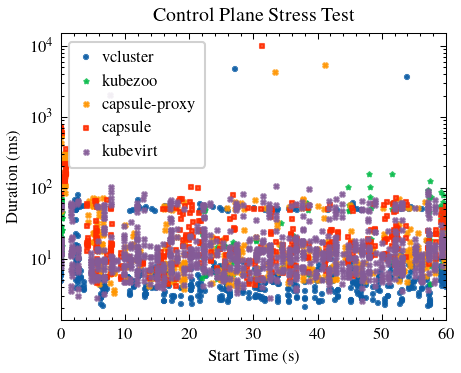

In [ ]:
# plot scatter

data = []
system_to_plot = "control_plane"
for exp_name, systems in experiments.items():
        for system_name, metrics in systems.items():
                if system_name != system_to_plot:
                    continue
                baseline_metrics = metrics["baseline"]  
                unbalanced_metrics = metrics["stress_test"]
                # Extract raw data for tenant 1 from the stress test
                t1_data = unbalanced_metrics.t1_df
                # Extract start time and duration for tenant 1
                start_times = t1_data['start_time'] - t1_data['start_time'].min()  # Normalize to start at 0
                durations = t1_data['duration_ms']
                # Append to data list with label
                data.append((exp_name, start_times, durations))



plt.style.use(['science','scatter'])
fig, ax = plot_for_paper(dpi=150)
plot_scatter(data, ax, title='Control Plane Stress Test', xlabel='Start Time (s)', ylabel='Duration (ms)', filename='control_plane_stresstest_scatter')

Loading data from all solutions for regular tenant comparison...


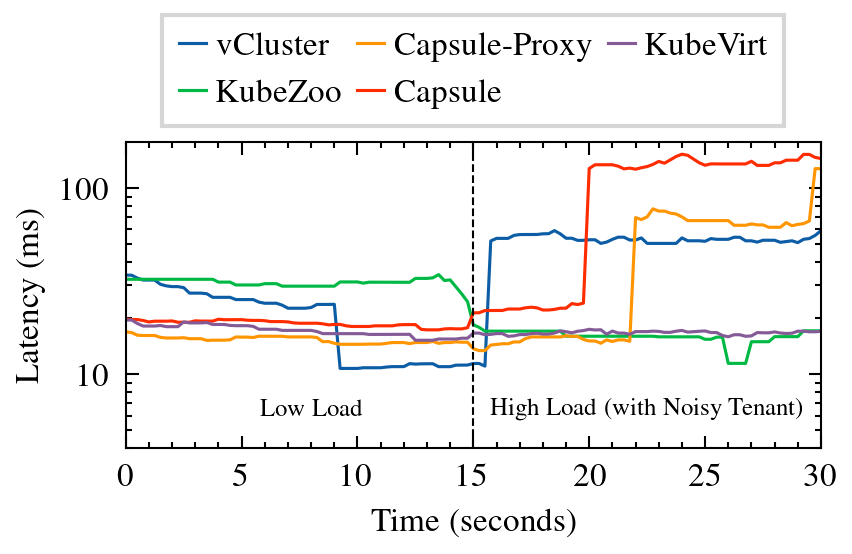

In [451]:
plt.style.use(['science'])
plot_t1_latency_comparison_across_solutions(experiments, system="control_plane", save_plots=True, out_dir="./", single_column_size=True, max_duration=30)

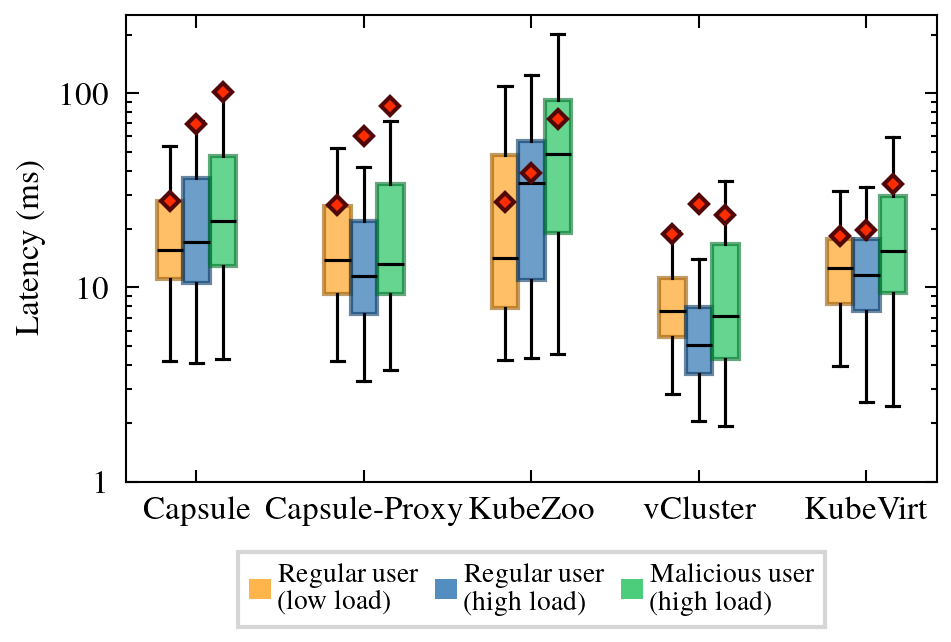


COMPARATIVE LATENCY ANALYSIS

VCLUSTER:
  Baseline:
    Requests: 592
    Mean: 18.8ms
    Median: 7.6ms
    P95: 53.5ms
    P99: 79.9ms
    Std Dev: 124.1ms
  Regular Tenant:
    Requests: 528
    Mean: 26.8ms
    Median: 5.1ms
    P95: 52.3ms
    P99: 65.0ms
    Std Dev: 256.4ms
  Malicious Tenant:
    Requests: 4,160
    Mean: 23.7ms
    Median: 7.1ms
    P95: 51.7ms
    P99: 79.3ms
    Std Dev: 245.1ms

KUBEZOO:
  Baseline:
    Requests: 232
    Mean: 27.5ms
    Median: 14.2ms
    P95: 75.2ms
    P99: 101.0ms
    Std Dev: 26.0ms
  Regular Tenant:
    Requests: 216
    Mean: 38.9ms
    Median: 34.6ms
    P95: 100.5ms
    P99: 123.2ms
    Std Dev: 30.9ms
  Malicious Tenant:
    Requests: 1,752
    Mean: 73.4ms
    Median: 48.7ms
    P95: 166.0ms
    P99: 344.3ms
    Std Dev: 409.6ms

CAPSULE-PROXY:
  Baseline:
    Requests: 608
    Mean: 26.7ms
    Median: 13.8ms
    P95: 76.9ms
    P99: 152.0ms
    Std Dev: 53.3ms
  Regular Tenant:
    Requests: 416
    Mean: 60.3ms
    Median: 11.

In [542]:
plot_comparative_latency_distribution(experiments, system="control_plane", save_plots=True, out_dir="./", single_column_size=True)

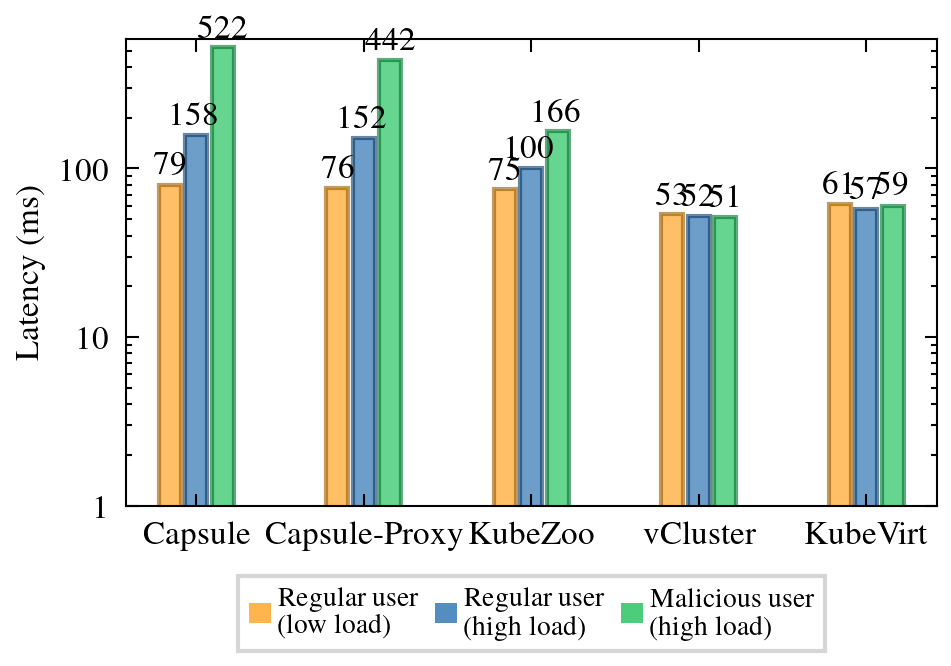


COMPARATIVE LATENCY ANALYSIS

VCLUSTER:
  Baseline:
    Requests: 592
    Mean: 18.8ms
    Median: 7.6ms
    P95: 53.5ms
    P99: 79.9ms
    Std Dev: 124.1ms
  Regular Tenant:
    Requests: 528
    Mean: 26.8ms
    Median: 5.1ms
    P95: 52.3ms
    P99: 65.0ms
    Std Dev: 256.4ms
  Malicious Tenant:
    Requests: 4,160
    Mean: 23.7ms
    Median: 7.1ms
    P95: 51.7ms
    P99: 79.3ms
    Std Dev: 245.1ms

KUBEZOO:
  Baseline:
    Requests: 232
    Mean: 27.5ms
    Median: 14.2ms
    P95: 75.2ms
    P99: 101.0ms
    Std Dev: 26.0ms
  Regular Tenant:
    Requests: 216
    Mean: 38.9ms
    Median: 34.6ms
    P95: 100.5ms
    P99: 123.2ms
    Std Dev: 30.9ms
  Malicious Tenant:
    Requests: 1,752
    Mean: 73.4ms
    Median: 48.7ms
    P95: 166.0ms
    P99: 344.3ms
    Std Dev: 409.6ms

CAPSULE-PROXY:
  Baseline:
    Requests: 608
    Mean: 26.7ms
    Median: 13.8ms
    P95: 76.9ms
    P99: 152.0ms
    Std Dev: 53.3ms
  Regular Tenant:
    Requests: 416
    Mean: 60.3ms
    Median: 11.

In [469]:
plot_comparative_latency_distribution_p95(experiments, system="control_plane", save_plots=True, out_dir="./", single_column_size=True)

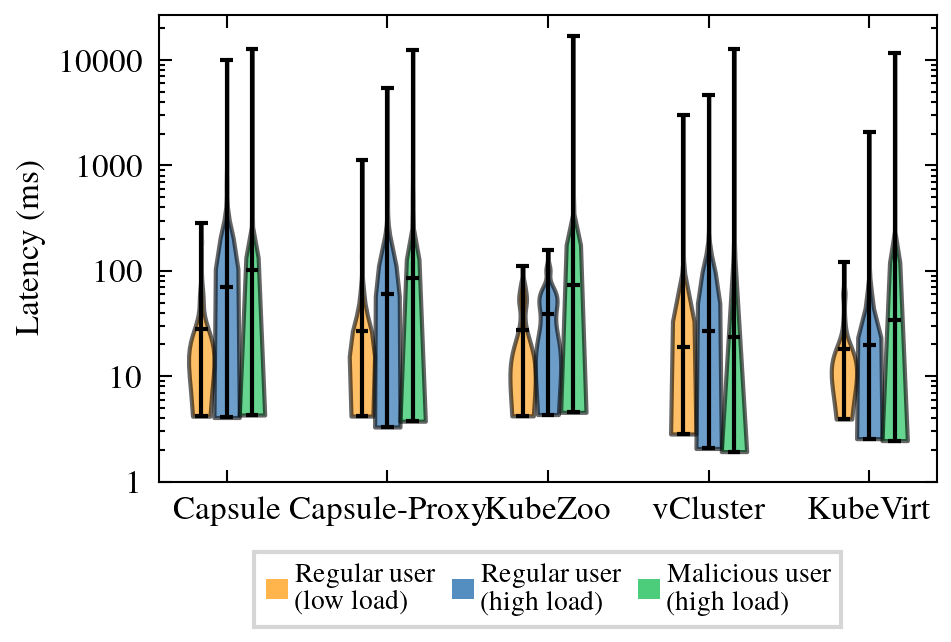


COMPARATIVE LATENCY ANALYSIS

VCLUSTER:
  Baseline:
    Requests: 592
    Mean: 18.8ms
    Median: 7.6ms
    P95: 53.5ms
    P99: 79.9ms
    Std Dev: 124.1ms
  Regular Tenant:
    Requests: 528
    Mean: 26.8ms
    Median: 5.1ms
    P95: 52.3ms
    P99: 65.0ms
    Std Dev: 256.4ms
  Malicious Tenant:
    Requests: 4,160
    Mean: 23.7ms
    Median: 7.1ms
    P95: 51.7ms
    P99: 79.3ms
    Std Dev: 245.1ms

KUBEZOO:
  Baseline:
    Requests: 232
    Mean: 27.5ms
    Median: 14.2ms
    P95: 75.2ms
    P99: 101.0ms
    Std Dev: 26.0ms
  Regular Tenant:
    Requests: 216
    Mean: 38.9ms
    Median: 34.6ms
    P95: 100.5ms
    P99: 123.2ms
    Std Dev: 30.9ms
  Malicious Tenant:
    Requests: 1,752
    Mean: 73.4ms
    Median: 48.7ms
    P95: 166.0ms
    P99: 344.3ms
    Std Dev: 409.6ms

CAPSULE-PROXY:
  Baseline:
    Requests: 608
    Mean: 26.7ms
    Median: 13.8ms
    P95: 76.9ms
    P99: 152.0ms
    Std Dev: 53.3ms
  Regular Tenant:
    Requests: 416
    Mean: 60.3ms
    Median: 11.

In [479]:
plot_comparative_latency_distribution_violin(experiments, system="control_plane", save_plots=True, out_dir="./", single_column_size=True)